In [3]:
import pandas as pd
df = pd.read_csv("../data/Mall_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})

In [7]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Annual Income (k$)      200 non-null    int64
 1   Spending Score (1-100)  200 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


In [8]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [9]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

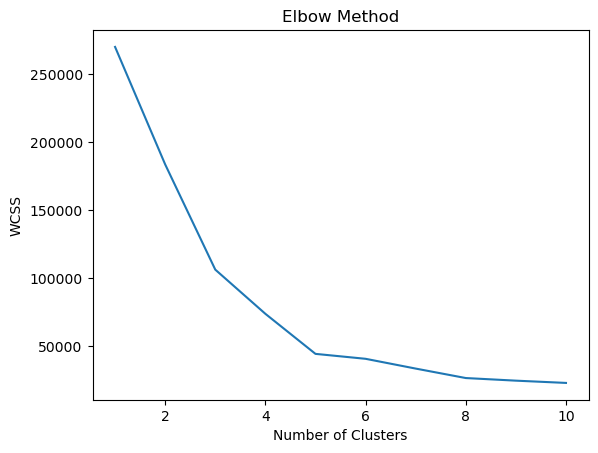

In [10]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

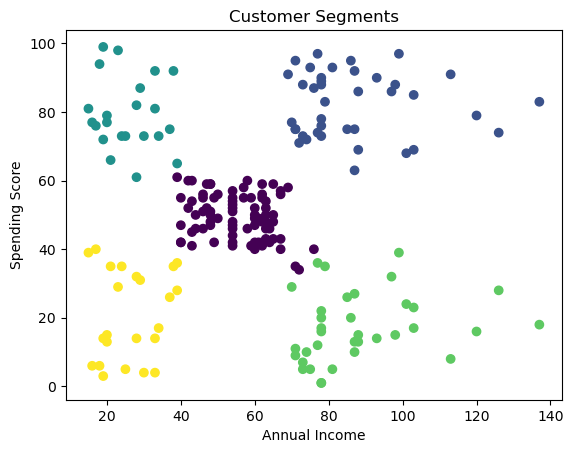

In [12]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans, cmap='viridis')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [13]:
print("Cluster Insights:")
print("Cluster 0: Medium income, medium spending")
print("Cluster 1: High income, high spending (Target customers)")
print("Cluster 2: Low income, low spending")
print("Cluster 3: High income, low spending")
print("Cluster 4: Low income, high spending")

Cluster Insights:
Cluster 0: Medium income, medium spending
Cluster 1: High income, high spending (Target customers)
Cluster 2: Low income, low spending
Cluster 3: High income, low spending
Cluster 4: Low income, high spending


In [14]:
import joblib
joblib.dump(kmeans, "../model/kmeans_model.pkl")

['../model/kmeans_model.pkl']

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
kmeans_scaled = KMeans(n_clusters=5, random_state=42)
y_scaled = kmeans_scaled.fit_predict(X_scaled)

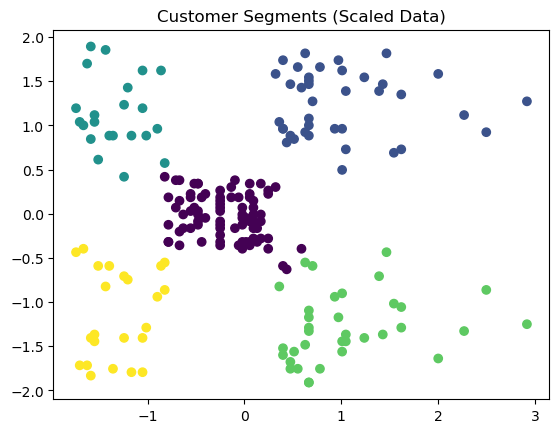

In [32]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_scaled, cmap='viridis')
plt.title("Customer Segments (Scaled Data)")
plt.show()

In [34]:
df['Cluster'] = y_scaled
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,0,19,15,39,4
1,2,0,21,15,81,2
2,3,1,20,16,6,4
3,4,1,23,16,77,2
4,5,1,31,17,40,4


In [36]:
df.groupby('Cluster').mean()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,86.320988,0.592593,42.716049,55.296296,49.518519
1,162.000000,0.538462,32.692308,86.538462,82.128205
2,23.090909,0.590909,25.272727,25.727273,79.363636
3,164.371429,0.457143,41.114286,88.200000,17.114286
4,23.000000,0.608696,45.217391,26.304348,20.913043


In [38]:
df['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [40]:
cluster_summary = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean',
    'CustomerID': 'count'
})

cluster_summary.rename(columns={'CustomerID': 'Customer Count'}, inplace=True)

cluster_summary

,Annual Income (k$),Spending Score (1-100),Age,Customer Count
Cluster,,,,
0,55.296296,49.518519,42.716049,81
1,86.538462,82.128205,32.692308,39
2,25.727273,79.363636,25.272727,22
3,88.200000,17.114286,41.114286,35
4,26.304348,20.913043,45.217391,23


In [42]:
cluster_names = {
    0: "Premium Customers",
    1: "Careful Rich",
    2: "Budget Spenders",
    3: "Low Value Customers",
    4: "Average Customers"
}

df['Segment'] = df['Cluster'].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,0,19,15,39,4,Average Customers
1,2,0,21,15,81,2,Budget Spenders
2,3,1,20,16,6,4,Average Customers
3,4,1,23,16,77,2,Budget Spenders
4,5,1,31,17,40,4,Average Customers


In [44]:
import joblib

joblib.dump(kmeans_scaled, "../model/kmeans_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']